In [1]:

import re
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from scipy.special import kn, kve


import BOLEH as bl

from scipy.integrate import quad

from scipy.interpolate import interp1d


In [2]:


#Define scalar and matrix constants.
v=174
# ===============================================================
#PMNS parameters
thetaN12=33.44*np.pi/180
thetaN23=49.2*np.pi/180
thetaN13=8.57*np.pi/180
deltaCP=197*np.pi/180 * 1j

#PMNS matrix
Upmns=np.array([[np.cos(thetaN12)*np.cos(thetaN13), np.sin(thetaN12)*np.cos(thetaN13), np.sin(thetaN13)*np.exp(-1*deltaCP)],
               [-np.sin(thetaN12)*np.cos(thetaN23)-np.cos(thetaN12)*np.sin(thetaN23)*np.sin(thetaN13)*np.exp(deltaCP),
                np.cos(thetaN12)*np.cos(thetaN23)-np.sin(thetaN12)*np.sin(thetaN23)*np.sin(thetaN13)*np.exp(deltaCP), np.sin(thetaN23)*np.cos(thetaN13)]
               ,[np.sin(thetaN12)*np.sin(thetaN23)-np.cos(thetaN12)*np.cos(thetaN23)*np.sin(thetaN13)*np.exp(deltaCP),
                -np.cos(thetaN12)*np.sin(thetaN23)-np.sin(thetaN12)*np.cos(thetaN23)*np.sin(thetaN13)*np.exp(deltaCP), np.cos(thetaN23)*np.cos(thetaN13)]]
               ,dtype=complex)
UpmnsDag = Upmns.conj().T

r = 1.3

#mDiag neutrinos
m_vDiag= np.array([[ 1e-12, 0, 0],
 [0, 8.672e-12, 0],
 [0, 0, 5.018e-11]], dtype=complex)

#Flavour change matrix
#VE=traspose(Upmns.conj()) #np.eye(n)
VE=np.eye(3)
VEDag=VE.conj().T

#m_V^{II}
m_vII=r*VE.T @ Upmns.conj() @ m_vDiag @ UpmnsDag @ VE

#Yukawa
yE_diag = np.array([[ 2.8e-6, 0, 0],
 [0, 5.9e-4, 0],
 [0, 0, 1e-2]], dtype=complex)

yE = VEDag @ yE_diag @ VE

#Type II benchmark couplings
mT = 1j*m_vII
mH = (1-1j)*m_vII
MT = 1e11
mu = 0.1*MT

#f coupling 
f = (2*mT*MT**2/(mu* v**2))
fDag = f.conj().T
ffDag = f@fDag

#Branching ratios
Bl= np.trace(ffDag)/(np.trace(ffDag)+mu**2/MT**2)
BH=(mu**2/MT**2)/(np.trace(ffDag)+mu**2/MT**2)

mTdagger = mT.conj().T
mHdagger = mH.conj().T
mTmHdagger = mT @ mHdagger
mHmTdagger = mH @ mTdagger
mTdaggermT = mTdagger@ mT
#CP violation
epsilonII=1j/(8*np.pi) * MT/v**2 * np.sqrt(Bl*BH) * (mTmHdagger-mHmTdagger)/(np.sqrt(np.trace(mTdaggermT)))
print(epsilonII)



######################################################################
#Define a suitable Mref
bl.config["Mref"] = MT
Mref=bl.config["Mref"]


[[-2.31155896e-08+9.25383214e-27j  7.14746234e-08+2.38260845e-08j
   7.47492542e-08+2.05661245e-08j]
 [ 7.14746234e-08-2.38260845e-08j -4.21296078e-07+1.68656879e-25j
  -3.48913817e-07-4.35398004e-10j]
 [ 7.47492542e-08-2.05661245e-08j -3.48913817e-07+4.35398004e-10j
  -3.15370727e-07+1.26251929e-25j]]
2518.0323999997113


In [3]:
#gamma_A integration

g22=np.sqrt(4*np.pi*0.0337)
gy=np.sqrt(4*np.pi*0.0169)
def sigmaA(x):
    sigmaa=1/(16*np.pi*x**2)*(x**(1/2)*(x-4)**(1/2)*(96*g22**2*gy**2*(x+4)+gy**4*(65*x-68)+2*g22**4*(172+65*x))
                               -96*(4*g22**2*gy**2*(x-2)+gy**4*(x-2)+4*g22**4*(x-1))*np.log((np.sqrt((x-4)*x)+x-2)/2))
    return sigmaa
def integrand(t,z):
    return 2*t**2*kn(1,z*t)*sigmaA(t**2)
def gammaAII(z):
    I1, err1 = quad(integrand,2,70,args=(z,))
    #I2, err2 = quad(integrand,1e70,np.inf,args=(z,))
    #I=I1+I2
    gammaaaa=MT**4/(64*np.pi**4*z)*I1
    #print(err)
    return gammaaaa

zforA= np.logspace(-7,5,2000)

gammaA_values = []

for z in zforA:
    val=gammaAII(z)
    gammaA_values.append(val)

data = np.column_stack((zforA, gammaA_values))
np.savetxt(
    "gammaA_table.txt",
    data,
    header= "z gammaA"
)
#gamma_A interpolation
datas=np.loadtxt("gammaA_table.txt")

zforA= datas[:,0]
gammaA_vals=datas[:,1]
gammaA_interp=interp1d(np.log(zforA), np.log(gammaA_vals), kind="linear", bounds_error=False, fill_value=(np.log(gammaA_vals[0]),np.log(gammaA_vals[-1])))

C:\Users\Sergio Cubides\AppData\Local\Temp\ipykernel_23264\1954472926.py:12: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  I1, err1 = quad(integrand,2,70,args=(z,))
C:\Users\Sergio Cubides\AppData\Local\Temp\ipykernel_23264\1954472926.py:38: RuntimeWarning: divide by zero encountered in log
  gammaA_interp=interp1d(np.log(zforA), np.log(gammaA_vals), kind="linear", bounds_error=False, fill_value=(np.log(gammaA_vals[0]),np.log(gammaA_vals[-1])))


In [4]:

def YETeq(z):
    yneq1=(135/(2*np.pi**4 * bl.geff))* z**2 * kn(2,z)
    return yneq1


def gammaDII(z):  
    Gamman = MT/(32*np.pi) * (np.trace(f@fDag)+mu**2/MT**2)
    ratio = kve(1,z)/kve(2,z)
    gammaDIII = Gamman * ratio/(bl.Hubble(z)*z)#This is already gamma_D/YETeq
    return gammaDIII

def gammaA(z):
    return np.exp(gammaA_interp(np.log(z)))/((YETeq(z)+1e-120)**2 * bl.s(z)*bl.Hubble(z)*z)



In [5]:
def WII(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    YDT=y_newphys[1]
    
    factor1 = 2 * gammaDII(z) / ((ffDag).trace() + mu**2 / MT**2)
    YDL=YDL.T
    termino1 = (ffDag) * (YDT)
    
    # Usamos YDl_safe para limpiar termino2 y termino34
    termino2 = 2 * (f @ YDL.T )@ fDag
    termino34 = (ffDag @ YDL) + (YDL @ ffDag)
    
    factor2 = termino1 + ( YETeq(z) / (4 * bl.Ynor * bl.gl * bl.Zetal)) * (termino2 + termino34)
    
    WI = factor1 * factor2
    
    return -WI.T

    
def SII(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    YET=y_newphys[0]
    Si = epsilonII * gammaDII(z) * (YET - YETeq(z))
    
    return Si

parameters = {"yU" : yU,
             "yE" : yE,
             "yD" : yD}
def dYET(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    YET = y_newphys[0]
    dYET1 = -gammaDII(z) * (YET-YETeq(z)) - 2 * gammaA(z) * (YET**2 - YETeq(z)**2)
    return dYET1

def dYDT(z,y_newphys, YDL, YDE, YDH, YDQ, YDU, YDD):
    YDT = y_newphys[1]
    YET = y_newphys[0]
    dYDT1 = -gammaDII(z) * (YDT + YETeq(z) * (Bl*((ffDag@YDL).trace() /(ffDag.trace()*bl.Ynor*bl.gl*bl.Zetal)) - BH * ((1/3) * YDH.trace() / (bl.Ynor*bl.gH*bl.ZetaH))))
    return dYDT1

TypeII = {"NEW_DEGREES_OF_FREEDOM" : [dYET, dYDT],
         "YDL":[WII, SII],
         "HYPERCHARGES": {1:1}}

functions_to_protect = ['YETeq', 'gammaDII', 'gammaA']

ynew0=np.zeros(2)

In [6]:
zspan = [1e-4, 1e4]
results = bl.SolveBE(zspan, ynew0,
    contributions = TypeII,
    background_funcs = functions_to_protect,
    filename= 'Type_II'
    #plot=True
)

--- Jacobian Analitic Matrix---
---Lambyfy ---
Time of Jacobian calcultaion = 5.3048 seconds.
End of Jacobian and Ode
Time of numerical integration = 0.3860 seconds.
✅ Data saved successfully to HDF5: Type_II.h5
Final $B-L$ asymmetry (Full covariant formalism): 3.7594e-10


In [7]:

TypeIIL = {"NEW_DEGREES_OF_FREEDOM" : [dYET, dYDT],
         "YTDelta":[WII, SII],
         "HYPERCHARGES": {1:1}}

resultsL = bl.SolveBELE(zspan, ynew0,
    contributions = TypeIIL,
    background_funcs = functions_to_protect,
    filename='Type_IIL'
)

--- Analytical Jacobian Matrix ---
--- Lambdify ---
Time of Jacobian calculation =  4.8763 seconds.
End of Jacobian and Ode
Time for numerical integration = 0.2072 seconds.
✅ Data saved successfully to HDF5: Type_IIL.h5
Final $Y_B$ (effective Lepton-flavor covariant formalism): 3.6157e-10


--- LEPTOGENESIS ALONE ---
Final Y_B = 1.1389353382556944e-10
Final eta_B = 8.016965845981833e-10

--- FULL BARYOGENESIS (WITH QUARKS) ---
Final Y_B = 1.1841973359550116e-10
Final eta_B = 8.335565047787326e-10



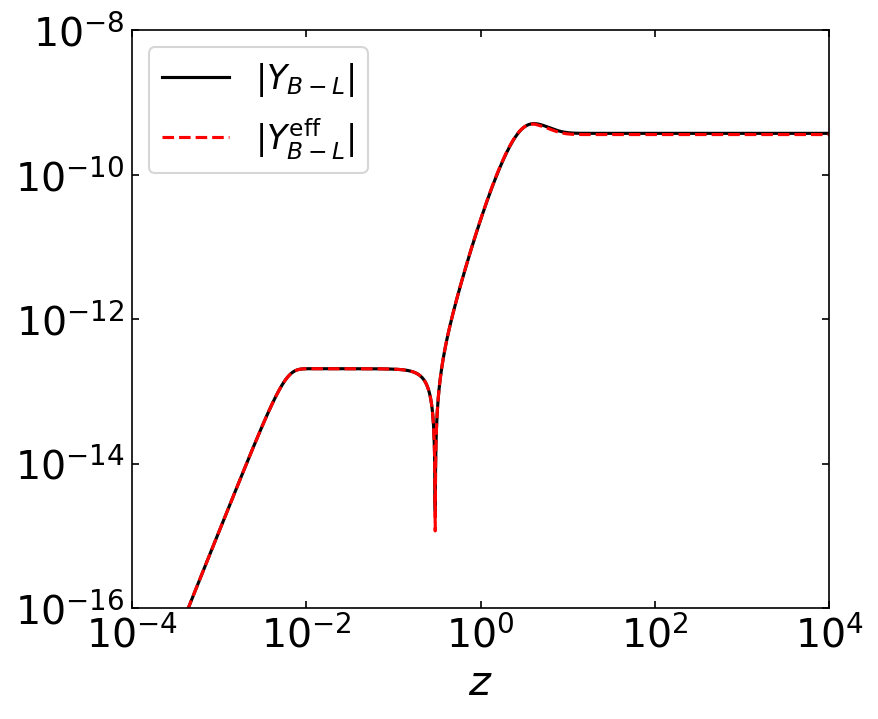

In [8]:
z_L = resultsL["z"]
YBL_L = resultsL["YBL"]
y_np_B = np.array(results["y_newphys"])
y_np = np.array(resultsL["y_newphys"])

z_B = results["z"]

YBL_B =results["YBL"]

YBSM_L = np.abs( 0.315*YBL_L[-1])
etaB_L = 7.039 * YBSM_L
print("--- LEPTOGENESIS ALONE ---")
print(f"Final Y_B = {YBSM_L}")
print(f"Final eta_B = {etaB_L}\n")

YBSM_B = np.abs(0.315 * YBL_B[-1])
etaB_B = 7.039 * YBSM_B
print("--- FULL BARYOGENESIS (WITH QUARKS) ---")
print(f"Final Y_B = {YBSM_B}")
print(f"Final eta_B = {etaB_B}\n")

plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16



plt.plot(
    z_B,
    np.abs(YBL_B),
    
    label=r'$|Y_{B-L}|$',
    color='black',
    linestyle='-',
    linewidth=1.5
)
plt.plot(
    z_L,
    np.abs(YBL_L),
    label=r'$|Y_{B-L}^{\rm eff}|$',
    color='red',
    linestyle='--',
    linewidth=1.5
)
title="BL SSII"
    
plt.xlim(1e-4,1e4)
plt.ylim(1e-16,1e-8)
plt.xlabel(r'$z$')
#plt.ylabel(r'$|Y_{B-L}|$')
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()

filename = re.sub(r'[^\w\s-]', '', title)
filename = filename.replace('at', '')
filename = "_".join(filename.split())
filename = filename.strip('_') + ".png"

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Sergio Cubides\AppData\Local\Temp\ipykernel_17308\1912493935.py:25: RuntimeWarning: invalid value encountered in divide
  c_H2= -(1/3)*(-tr_DQ_B -4*tr_DU_B + 2*tr_DD_B + 3*tr_DL_B


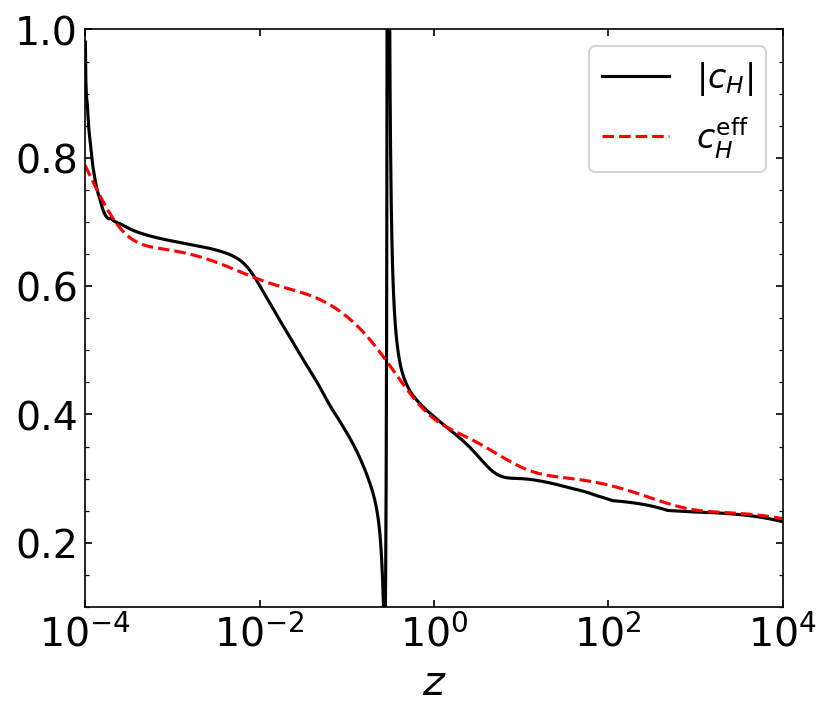

✅ Plot saved as: CH_SSII.png


In [9]:
#plt.figure(figsize=(8, 5))
z_B = results["z"]
YDL_B = results["YDL"]
YDE_B = results["YDE"]
YDQ_B = results["YDQ"]
YDU_B = results["YDU"]
YDD_B = results["YDD"]

YET_B = y_np_B[:,0]      
YDT_B = y_np_B[:,1]
tr_DL_B = np.array([np.trace(m) for m in YDL_B])
tr_DE_B = np.array([np.trace(m) for m in YDE_B])
tr_DQ_B = np.array([np.trace(m) for m in YDQ_B])
tr_DU_B = np.array([np.trace(m) for m in YDU_B])
tr_DD_B = np.array([np.trace(m) for m in YDD_B])
# 1. Set the uniform plot size
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150


plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
c_H2= -(1/3)*(-tr_DQ_B -4*tr_DU_B + 2*tr_DD_B + 3*tr_DL_B
               +6*tr_DE_B-6*YDT_B)/(1/3 *
    (tr_DQ_B + tr_DU_B + tr_DD_B)
  - tr_DL_B
  - 2*tr_DE_B+ 2*YDT_B )

plt.plot(
    z_B,
    np.abs(c_H2),
    label=r'$|c_H|$',
    color='black'
)
plt.plot(z_B,
    np.abs(bl.ch(z_B)),
    label=r'$c_H^{\rm eff}$',
    color='red',
    linestyle='--')

title="CH SSII"

plt.xlim(1e-4,1e4)
plt.ylim(1e-1,1e0)
plt.xlabel(r'$z$')
#plt.ylabel(r'$c_{H}$')
plt.xscale('log')
#plt.yscale('log')
#plt.title('Normal Ordering')
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()
#plt.savefig('Trace.png', dpi=300)

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"     


plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")

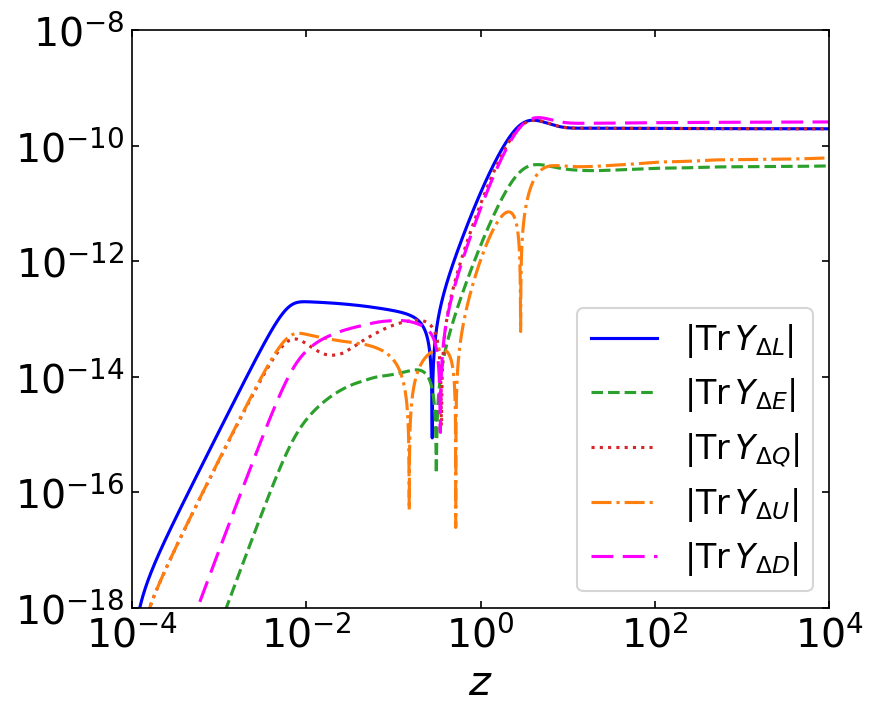

✅ Plot saved as: Ferm_SSII.png


In [10]:
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['figure.dpi'] = 150

# 2. Set the uniform font sizes
#plt.rcParams['axes.titlesize'] = 12     # Title font size
#plt.rcParams['axes.titleweight'] = 'bold' # Bold title
plt.rcParams['axes.labelsize'] = 20     # X and Y label font size
plt.rcParams['xtick.labelsize'] = 19    # X axis tick size
plt.rcParams['ytick.labelsize'] = 19   # Y axis tick size
plt.rcParams['legend.fontsize'] = 16
plt.plot(
    z_B, np.abs(tr_DL_B),
    lw=1.5, color='blue', ls='-',
    label=r'$|\mathrm{Tr}\,Y_{\Delta L}|$'
)

plt.plot(
    z_B, np.abs(tr_DE_B),
    lw=1.5, color='tab:green', ls='--',
    label=r'$|\mathrm{Tr}\,Y_{\Delta E}|$'
)

plt.plot(
    z_B, np.abs(tr_DQ_B),
    lw=1.5, color='tab:red', ls=':',
    label=r'$|\mathrm{Tr}\,Y_{\Delta Q}|$'
)

plt.plot(
    z_B, np.abs(tr_DU_B),
    lw=1.5, color='tab:orange', ls='-.',
    label=r'$|\mathrm{Tr}\,Y_{\Delta U}|$'
)

plt.plot(
    z_B, np.abs(tr_DD_B),
    lw=1.5, color='magenta', ls=(0, (7, 3)),
    label=r'$|\mathrm{Tr}\,Y_{\Delta D}|$'
)


title = "Ferm SSII"
plt.xlabel(r'$z$')
#plt.ylabel(r'$|\rm{Tr}(Y_{\Delta i})|$')
plt.xlim(1e-4,1e4)
plt.ylim(1e-18,1e-8)
plt.xscale('log')
plt.yscale('log')
plt.minorticks_on()
#plt.title(title)
plt.minorticks_on()
plt.tick_params(which='both', top=True, right=True, direction='in')
plt.legend()

filename = re.sub(r'[^\w\s-]', '', title)   
filename = filename.replace('at', '')       
filename = "_".join(filename.split())       
filename = filename.strip('_') + ".png"    

plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Plot saved as: {filename}")